In [1]:
import numpy as np

In [2]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 50.1k/50.1k [00:00<00:00, 148kB/s]

Extracting files...
Path to dataset files: C:\Users\gurra\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [3]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [4]:
import pandas as pd
import os

file_path = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = pd.read_csv(file_path)

print(df.head())
print(df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [10]:
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


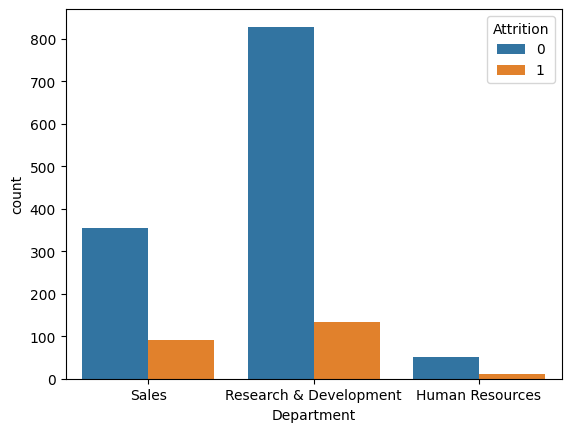

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Department', hue='Attrition', data=df)
plt.show()

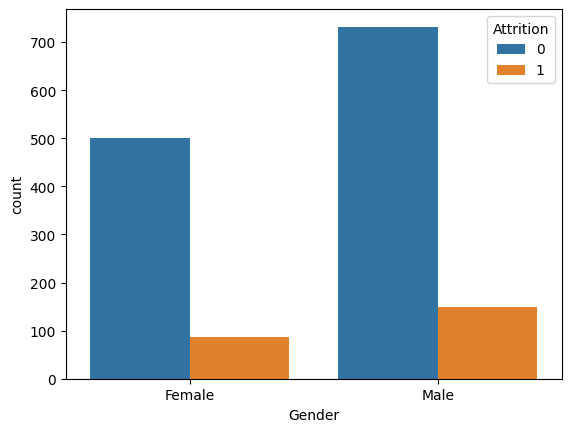

In [12]:
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.show()

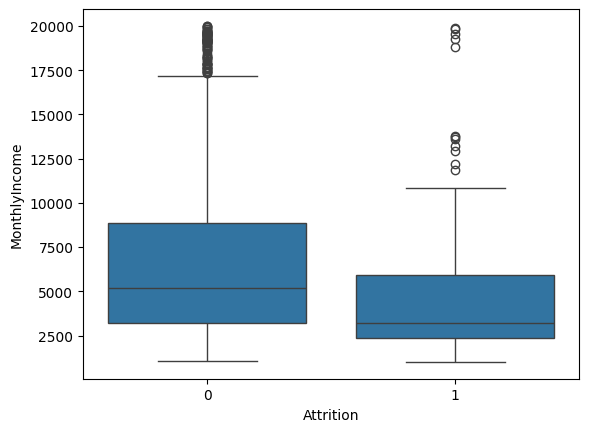

In [13]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

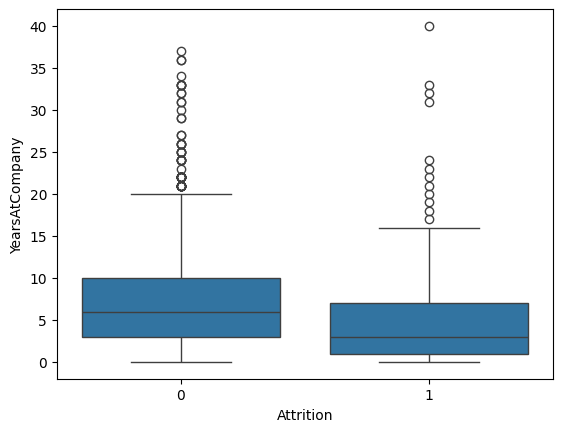

In [14]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.show()

In [15]:
# Convert target
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

# Drop useless columns
df.drop(['EmployeeNumber','EmployeeCount','Over18','StandardHours'], axis=1, inplace=True)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Split X and y
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
print(df['Attrition'].dtype)
print(df['Attrition'].head())

float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Attrition, dtype: float64


In [21]:
df['Attrition'] = df['Attrition'].astype(str)

In [22]:
df['Attrition'] = df['Attrition'].str.strip()

In [23]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [25]:
df = pd.read_csv(file_path)

In [34]:
df['Attrition'] = (
    df['Attrition']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

In [35]:
df = df.dropna(subset=['Attrition'])

In [36]:
df['Attrition'] = df['Attrition'].astype(int)

In [37]:
print("NaN in Attrition:", df['Attrition'].isna().sum())
print(df['Attrition'].value_counts())

NaN in Attrition: 0
Series([], Name: count, dtype: int64)


In [39]:
print(df.shape)
print(df.head())

(0, 35)
Empty DataFrame
Columns: [Age, Attrition, BusinessTravel, DailyRate, Department, DistanceFromHome, Education, EducationField, EmployeeCount, EmployeeNumber, EnvironmentSatisfaction, Gender, HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction, MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked, Over18, OverTime, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StandardHours, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager]
Index: []

[0 rows x 35 columns]


In [38]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [26]:
df['Attrition'] = df['Attrition'].astype(str).str.strip().str.lower()

In [27]:
df['Attrition'] = df['Attrition'].map({'yes': 1, 'no': 0})

In [28]:
df = df.dropna(subset=['Attrition'])

In [29]:
df['Attrition'] = df['Attrition'].astype(int)

In [30]:
df['Attrition'] = (
    df['Attrition']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

df = df.dropna(subset=['Attrition'])
df['Attrition'] = df['Attrition'].astype(int)

In [31]:
print(df['Attrition'].isna().sum())
print(df['Attrition'].value_counts())

0
Series([], Name: count, dtype: int64)


In [40]:
import pandas as pd

df = pd.read_csv(file_path)
print(df.shape)

(1470, 35)


In [41]:
df['Attrition'] = (
    df['Attrition']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [42]:
print(df['Attrition'].unique())

['yes' 'no']


In [43]:
df['Attrition'] = df['Attrition'].map({'yes': 1, 'no': 0})

In [44]:
df = df.dropna(subset=['Attrition'])

In [45]:
print(df.shape)
print(df['Attrition'].value_counts())

(1470, 35)
Attrition
0    1233
1     237
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT (handles imbalance properly)
)

In [48]:
df = pd.read_csv(file_path)

In [49]:
df['Attrition'] = df['Attrition'].str.strip().str.lower().map({'yes':1,'no':0})
df = df.dropna(subset=['Attrition'])
df['Attrition'] = df['Attrition'].astype(int)

In [50]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [51]:
X = pd.get_dummies(X, drop_first=True)

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
file_path = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = pd.read_csv(file_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [55]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

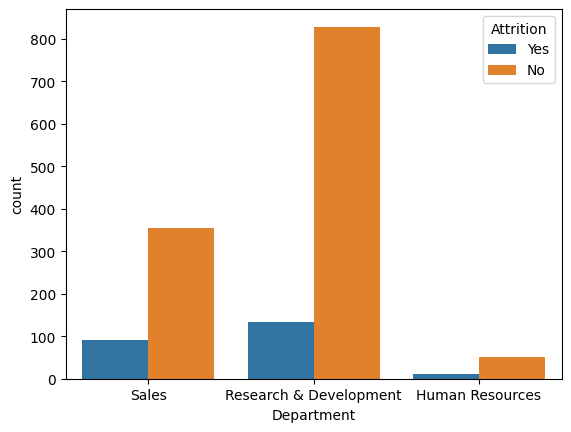

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Department', hue='Attrition', data=df)
plt.show()

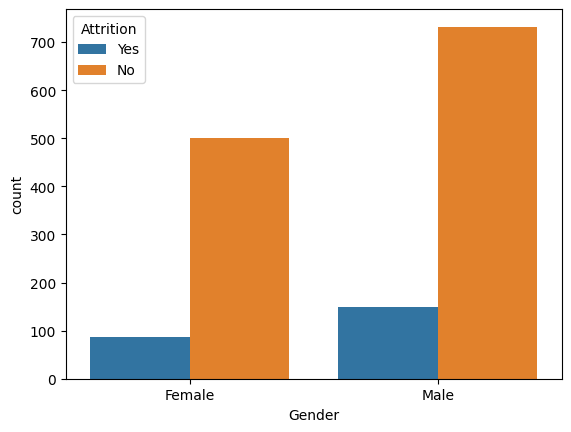

In [57]:
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.show()

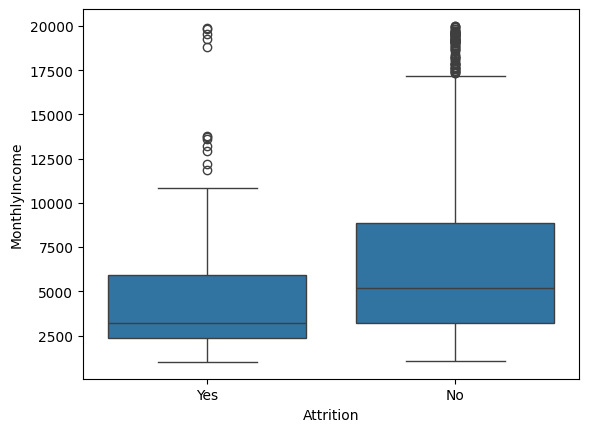

In [58]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

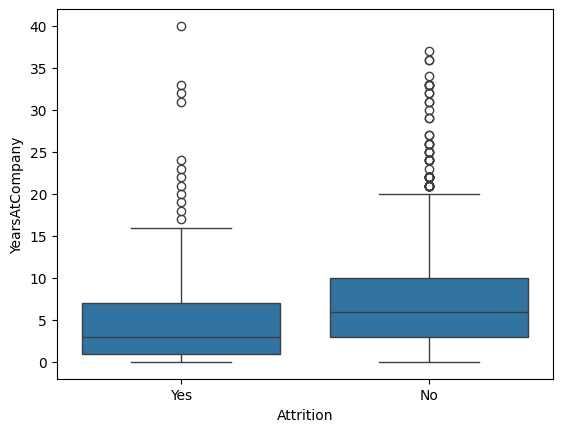

In [59]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.show()

In [60]:
df['Attrition'] = (
    df['Attrition']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

df = df.dropna(subset=['Attrition'])
df['Attrition'] = df['Attrition'].astype(int)

In [61]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [62]:
X = pd.get_dummies(X, drop_first=True)

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [66]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained ")

Logistic Regression trained 
Decision Tree trained 
Random Forest trained 
SVM trained 
KNN trained 
Naive Bayes trained 


In [67]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.8605442176870748
Decision Tree Accuracy: 0.8367346938775511
Random Forest Accuracy: 0.8333333333333334
SVM Accuracy: 0.8673469387755102
KNN Accuracy: 0.8435374149659864
Naive Bayes Accuracy: 0.6224489795918368


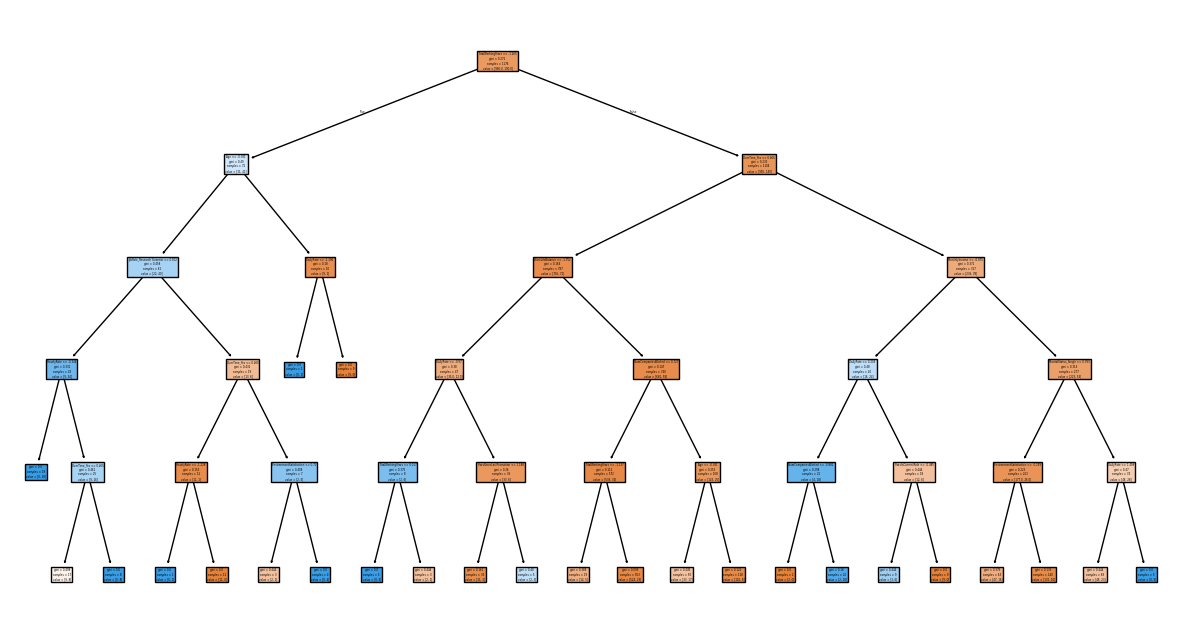

In [68]:
tree = models["Decision Tree"]

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.show()

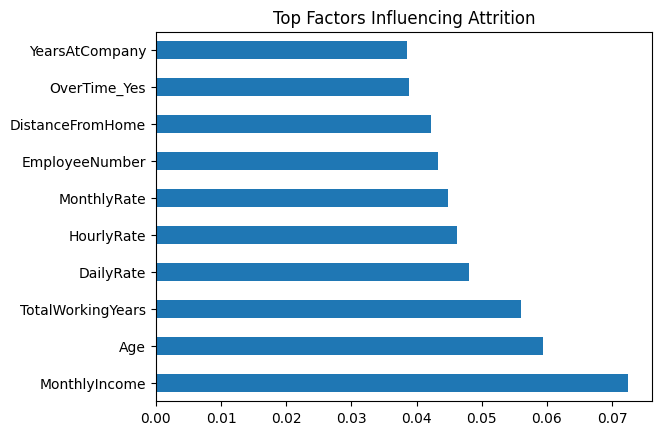

In [69]:
rf = models["Random Forest"]

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Factors Influencing Attrition")
plt.show()

In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)
print(X_pca.shape)

(1470, 5)


In [71]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

df[['Cluster']].head()

,Cluster
0,1
1,1
2,0
3,1
4,1


In [72]:
import pickle

pickle.dump(models["Random Forest"], open("random_forest.pkl", "wb"))
pickle.dump(models["Logistic Regression"], open("logistic_regression.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [73]:
import numpy as np
import pandas as pd

def predict_attrition(data_dict):
    model = pickle.load(open("random_forest.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))

    sample = pd.DataFrame([data_dict])
    sample = sample.reindex(columns=X.columns, fill_value=0)

    sample_scaled = scaler.transform(sample)

    prob = model.predict_proba(sample_scaled)[0][1] * 100

    return {
        "attrition_probability": round(prob, 2),
        "risk_level": "HIGH" if prob > 70 else "LOW"
    }

print(predict_attrition({
    "Age": 35,
    "MonthlyIncome": 4500,
    "JobSatisfaction": 2
}))

{'attrition_probability': np.float64(50.0), 'risk_level': 'LOW'}


In [74]:
def lambda_handler(event, context):
    result = predict_attrition(event)
    return result

In [75]:
import pickle

pickle.dump(models["Random Forest"], open("random_forest.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

In [76]:
pickle.load(open("columns.pkl", "rb"))

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
  

In [79]:
import pickle

pickle.dump(models["Random Forest"], open("random_forest.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(columns, open("columns.pkl", "wb"))

In [78]:
# After preprocessing
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X = pd.get_dummies(X, drop_first=True)

# IMPORTANT LINE (MISSING IN YOUR CODE)
columns = X.columns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pickle

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# SAVE EVERYTHING
pickle.dump(model, open("random_forest.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(columns, open("columns.pkl", "wb"))